# Testing Machine Learning For Algotrading
<br>
<b>About the project</b>
<br>
Doing this project I will try creatin a algotrading strategy using Machine Learning (ML). The project will be based on the following steps.
<br><br>
<ol>
    <li>1. Import data - The dataset used in this project will be based on a one minute dataset from AvaTrade.com</li>
    <ol>
        <li>Inspect data - Getting to know the data</li>
        <li>Visualizing the dataset</li> 
        <li>Data cleaning and transformation</li>
    </ol>
    <li>Feature engineering</li>
    <ol>
        <li>Create features</li>
    </ol>
    <li>Target engineering - Finding the dependent or target variable.</li>
    <li>Feature selection</li>
    <li>Split data - Create testing and training dataset</li>
    <ol>
        <li>Scaling the dataset</li>
    </ol>
    <li>Model testing</li>
    <ol>
        <li>Decision Tree Classifier</li>
        <li>KNeighbors Classifier</li>
        <li>Random Forest Classifier</li>
        <li>SVC (Support Vector Classifier)</li>
    </ol>    
</ol>

In [1]:
import pandas as pd

# Target creation
import quantreo.target_engineering as te
import quantstats as qs

# Feature
from Utility.FeatureEngineering import *
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

# System 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parameters
high_freq='4h'
tscv = TimeSeriesSplit(n_splits=5)

## Import data

In [ ]:
df = pd.read_parquet(r"Data/TIMEFRAME_GOLD_1M.parquet")

### Inspect data

First we are going to inspect the new dataframe. By the first glance it seems like the column 'Unnamed: 0' is a row definition from the source file and may be removed. Like the column 'real_volume' that only contains 0. 

In [4]:
df.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,,
2019-10-15 12:13:00,0,1492.87,1493.36,1492.77,1493.33,62,40,0
2019-10-15 12:14:00,1,1493.36,1493.47,1493.06,1493.07,47,40,0
2019-10-15 12:15:00,2,1493.09,1493.28,1492.97,1493.07,70,40,0
2019-10-15 12:16:00,3,1493.08,1493.35,1493.07,1493.35,28,40,0
2019-10-15 12:17:00,4,1493.30,1493.36,1493.14,1493.28,38,40,0


Next we are going to use the info() function to get informations about the columns and the index. That shows that we got a datafram with a DatetimeIndex and where the open, close, high and low columns is of float64 thats may be fine. Then we got the tick_volume and spread columns as int64 and thats fine too. 

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2199978 entries, 2019-10-15 12:13:00 to 2025-12-31 21:58:00
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   open         float64
 2   high         float64
 3   low          float64
 4   close        float64
 5   tick_volume  int64  
 6   spread       int64  
 7   real_volume  int64  
dtypes: float64(4), int64(4)
memory usage: 151.1 MB


Then we are going to check if there may be any rows where the 'tick_volume' is equal to 0. It is not the case else we was going to remove those rows.

In [6]:
df[df['tick_volume'] == 0].head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,,


### Visualizing the dataset 

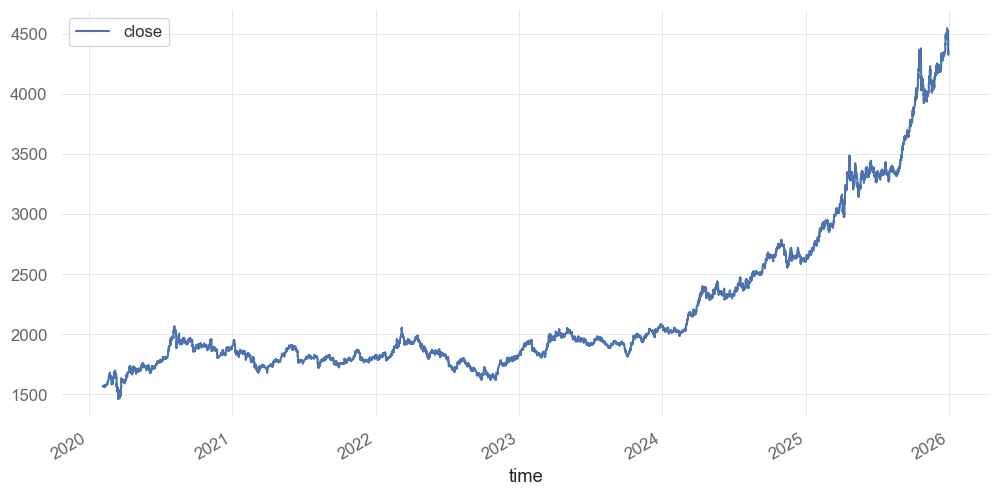

In [50]:
df.plot(y='close', figsize=(12,6));

### Data cleaning and transformation

First we are removing the columns 'Unnamed: 0' and 'real_volume'

In [7]:
df = df.drop(['Unnamed: 0', 'real_volume'], axis=1)

Just to be sure we are going to check for any missing values.

In [8]:
df.dropna(inplace=True)

Lastly the 'tick_volume' column is renamed to 'volume'  

In [9]:
df.rename(columns={'tick_volume': 'volume'}, inplace=True)

The dataset - Check out the first five rows

In [10]:
df.head()

,open,high,low,close,volume,spread
time,,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62,40
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47,40
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70,40
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28,40
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38,40


## Feature engineering
### Create features

In [11]:
featureEngineering = FeatureEngineering()
df = featureEngineering.get_features(df, high_freq)

9961
9750
9399
9054


The final dataset - Check out the last five rows

In [12]:
df.tail()

,open,high,low,close,volume,high_time,low_time,hurst,range,body,...,autocorr_20,autocorr_50,log_close,ret_log_1,ret_log_2,ret_log_5,ret_log_10,ret_log_20,ret_log_50,rolling_volatility_yang_zhang
time,,,,,,,,,,,,,,,,,,,,,
2025-12-29 08:00:00,4474.49,4488.34,4434.05,4446.59,86490,2025-12-29 08:17:00,2025-12-29 11:41:00,0.708477,54.29,-27.90,...,0.814925,0.812661,8.399893,-0.000742,-0.001853,-0.002045,-0.001286,-0.001065,0.004613,0.005802
2025-12-29 12:00:00,4446.77,4467.42,4301.79,4325.04,137193,2025-12-29 13:09:00,2025-12-29 15:22:00,0.671669,165.63,-121.73,...,0.764026,0.747230,8.372177,-0.003300,-0.004039,-0.005606,-0.004764,-0.004542,0.000151,0.006970
2025-12-29 16:00:00,4325.03,4347.25,4314.74,4336.90,92968,2025-12-29 16:55:00,2025-12-29 17:40:00,0.680253,32.51,11.87,...,0.732405,0.699525,8.374915,0.000327,-0.002974,-0.005095,-0.004675,-0.003284,0.000727,0.007030
2025-12-29 20:00:00,4336.89,4347.08,4323.05,4345.47,41813,2025-12-29 23:09:00,2025-12-29 23:18:00,0.677650,24.03,8.58,...,0.695599,0.658126,8.376889,0.000236,0.000563,-0.004586,-0.004406,-0.003910,0.001045,0.006755
2025-12-30 00:00:00,4345.47,4369.12,4324.32,4359.28,83437,2025-12-30 03:27:00,2025-12-30 01:05:00,0.683981,44.80,13.81,...,0.662786,0.614426,8.380062,0.000379,0.000615,-0.003101,-0.004989,-0.003858,0.000982,0.006884


Then we are going to check each column for missing values. And if any we are going to remove these rows

In [ ]:
print(df.isnull().sum().sort_values(ascending = False))

df = df.dropna()

rolling_volatility_yang_zhang    0
open                             0
high                             0
low                              0
spread                           0
                                ..
range                            0
hurst                            0
low_time                         0
high_time                        0
volume                           0
Length: 324, dtype: int64


In [14]:
print(f"The dataset contains {len(df)} rows.")

The dataset contains 9054 rows.


## Target engineering
As targe we will be using the future_returns_sign function from the Quantreo liberay <br>
https://docs.quantreo.com/tutorials/target-engineering-magnitude/#future-returns <br>
"The future_returns function computes the amplitude of the future return for each observation..
<ul>
    <li>You can choose between log-returns or simple returns.</li>
    <li>It’s particularly useful for regression models or for further feature engineering.</li>
</ul>
This will generate a trading signal where 1 = 'Buy' and 0 = 'Sell'"

### Finding best set of parameters.
The function takes one parameter the 'window_size' this parameter is definning the area of where the amplitude of the future return is calculated. <br>
We will be testing multiple windows_sizes in order to find the one that gives the higest return value.


In [15]:
# Creating a function to be used for calculating the return of the trading signal
def get_strategy_return(df, cols):
    df = df.copy()

    df['Return'] = df['close'].pct_change()
    df['Strategy_Return'] = df['Return'] * df[cols].shift(1)

    df = df.dropna()

    cumulative_return = (1 + df['Strategy_Return']).cumprod().iloc[-1]

    return cumulative_return

In [ ]:
results = []

for window_size in range(4 , 30, 1):
    df_copy = df.copy()

    df_copy['target_position'] = te.directional.future_returns_sign(df_copy, close_col='close', window_size=window_size, log_return=True)
    
    # Calculate daily returns
    CumulativeStrategyReturn = get_strategy_return(df_copy, 'target_position')

    #CumulativeStrategyReturn = qs.stats.comp(df_copy['strategy_return'])
    results.append({'window_size': window_size, 'CumulativeStrategyReturn': CumulativeStrategyReturn})
final_result = pd.DataFrame(results)
final_result = final_result.sort_values(by=['CumulativeStrategyReturn'], ascending=False )
print(final_result)

    window_size  CumulativeStrategyReturn
0             4               1297.252084
1             5                867.824491
2             6                553.729438
3             7                286.906587
4             8                223.406757
5             9                180.195128
6            10                155.895586
7            11                130.087348
8            12                104.108683
9            13                 85.500253
10           14                 65.442645
11           15                 60.193979
13           17                 51.395803
12           16                 50.528992
14           18                 47.847299
15           19                 47.609244
16           20                 38.799432
17           21                 38.319177
19           23                 34.004151
18           22                 33.946690
20           24                 29.428239
21           25                 28.179126
22           26                 25

### Creating the final target value
In the tests above the best result was at 637,81% return. This is perhaps a slightly unrealistic result, as it does not take into account trading costs. Furthermore, it should also be noted that the high result is based on a profit over approximately 8 years.

In [17]:
window_size = 4
df["target"] = te.directional.future_returns_sign(df, close_col='close', window_size=window_size, log_return=True)

In [18]:
df["target"].value_counts()

target
1    4856
0    4198
Name: count, dtype: int64

## Split data - Create testing and training dataset

In [19]:
# Define split ratios
train_ratio = 0.8

# Calculate split indices
train_length = int(len(df) * train_ratio)

# Perform splits
train_data = df[:train_length]
test_data = df[train_length:]

# Verify the splits
print(f"Training data: {len(train_data)} samples")
print(f"Test data: {len(test_data)} samples")

Training data: 7243 samples
Test data: 1811 samples


In [20]:
list_X = df.columns.to_list()
remove = {'target', 'high_time', 'low_time'}
list_X = list(filter(lambda x: x not in remove, list_X))

list_y = ['target']

x_train = train_data[list_X]
y_train = train_data[list_y]
x_test = test_data[list_X]
y_test = test_data[list_y]

### Scaling data
StandardScaler is a tool from scikit-learn that changes numbers in the dataset so they are on a similar scale.<br>
It does this by:<br>
<ol>
    <li>Making the average (mean) equal to 0</li>
    <li>Making the standard deviation equal to 1</li> 
</ol>

In simple terms, it adjusts the data so that no variable is much bigger or smaller than the others. This helps many machine learning models work better.

In [22]:
# Initialize the standardization model
sc = StandardScaler()
X_train_sc = sc.fit_transform(x_train)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=x_train.columns, index=x_train.index)


## Feature selection
At the moment our dataset contains 324 columns. In order to help our ML models making better and faster models, we have to reduce the number of column

### Intercorlinearity
Intercorlinearity also known as multicollinearity, happens when two or more independent variables in a dataset are highly correlated with each other. Meaning we got two variabels that trys to tell our model the same thing. We have to find the most important feature and remove the rest, because if we got these strong correlations between independent variables in our model, it may make our models unstable and that may decrease the performance of our model.<br> 
To find and remove the intercorlinearity our dataset we will be using the Variance Inflation Factor (VIF).  

In [23]:
def calculate_vif(df):
    """
    Calculate the Variance Inflation Factor (VIF) for each feature in a DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame containing the features for which VIF needs to be calculated.
        Ensure all features are numerical.

    Returns:
    --------
    vif_data : pandas.DataFrame
        A DataFrame containing two columns:
        - 'Feature': Names of the features.
        - 'VIF': Variance Inflation Factor values for each feature.
    """
    # Ensure all columns are numeric
    df_numeric = df.select_dtypes(include=[np.number])
    
    # Create a DataFrame to store VIF results
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_numeric.columns
    vif_data["VIF"] = [round(variance_inflation_factor(df_numeric.values, i), 2)
                       for i in range(df_numeric.shape[1])]
    return vif_data


def remove_intercolinarity(X_train, threshold=15):
    """
    Iteratively remove features with high multicollinearity based on the Variance Inflation Factor (VIF).

    Parameters:
    -----------
    X_train : pandas.DataFrame
        The input training dataset containing features.
    threshold : int or float, optional
        The VIF threshold above which features will be removed. Default is 15.

    Returns:
    --------
    vif_results : pandas.DataFrame
        The final DataFrame of VIF values for features after intercollinearity has been reduced.
    """
    # Create a copy of the training data
    X_train_bis = X_train.copy()

    # Calculate initial VIF for all features
    vif_results = calculate_vif(X_train_bis)
    vif_results = vif_results.set_index("Feature")
    
    # Identify the feature with the highest VIF
    name = vif_results.sort_values("VIF", ascending=False).iloc[0].name
    value = vif_results.sort_values("VIF", ascending=False).iloc[0].values[0]
    
    # Iteratively remove features with VIF higher than the threshold
    while value > threshold:
        
        # Remove the feature with the highest VIF
        del X_train_bis[name]

        # Recalculate VIF
        vif_results = calculate_vif(X_train_bis)
        vif_results = vif_results.set_index("Feature")
        
        # Identify the feature with the highest VIF
        name = vif_results.sort_values("VIF", ascending=False).iloc[0].name
        value = vif_results.sort_values("VIF", ascending=False).iloc[0].values[0]
    

    # Return the final VIF DataFrame
    return vif_results

In [ ]:
# First we are calculating the Variance Inflation Factor (VIF) 
calculate_vif(X_train_sc_df).sort_values("VIF", ascending=False).head(5)

,Feature,VIF
239,kama_50,2.530112e+13
224,kama_40,1.017993e+12
269,kama_70,9.088083e+11
299,kama_90,4.584516e+11
254,kama_60,2.497144e+11


In [ ]:
# Finaly we are going to reduce the numbers of columns vy using the Variance Inflation Factor (VIF) 
vif_results_clean = remove_intercolinarity(X_train_sc_df)
vif_results_clean

,VIF
Feature,
hurst,1.87
upper_shadow,4.56
lower_shadow,5.24
close_high_low_ratio,10.06
0_to_20,1.83
...,...
log_close,8.99
ret_log_1,9.34
ret_log_5,6.43


### Corretions
Then we can try create a function in order to see the correlation matrix. This function is creating two typs of correlstion.
But for now it is not that usefull because we got to many variabels.
<ol>
    <li>Left: Pearson correlation is a linear correlation.</li>
    <li>Right: Spearman correlation is a nonlinear correlation.</li> 
</ol>


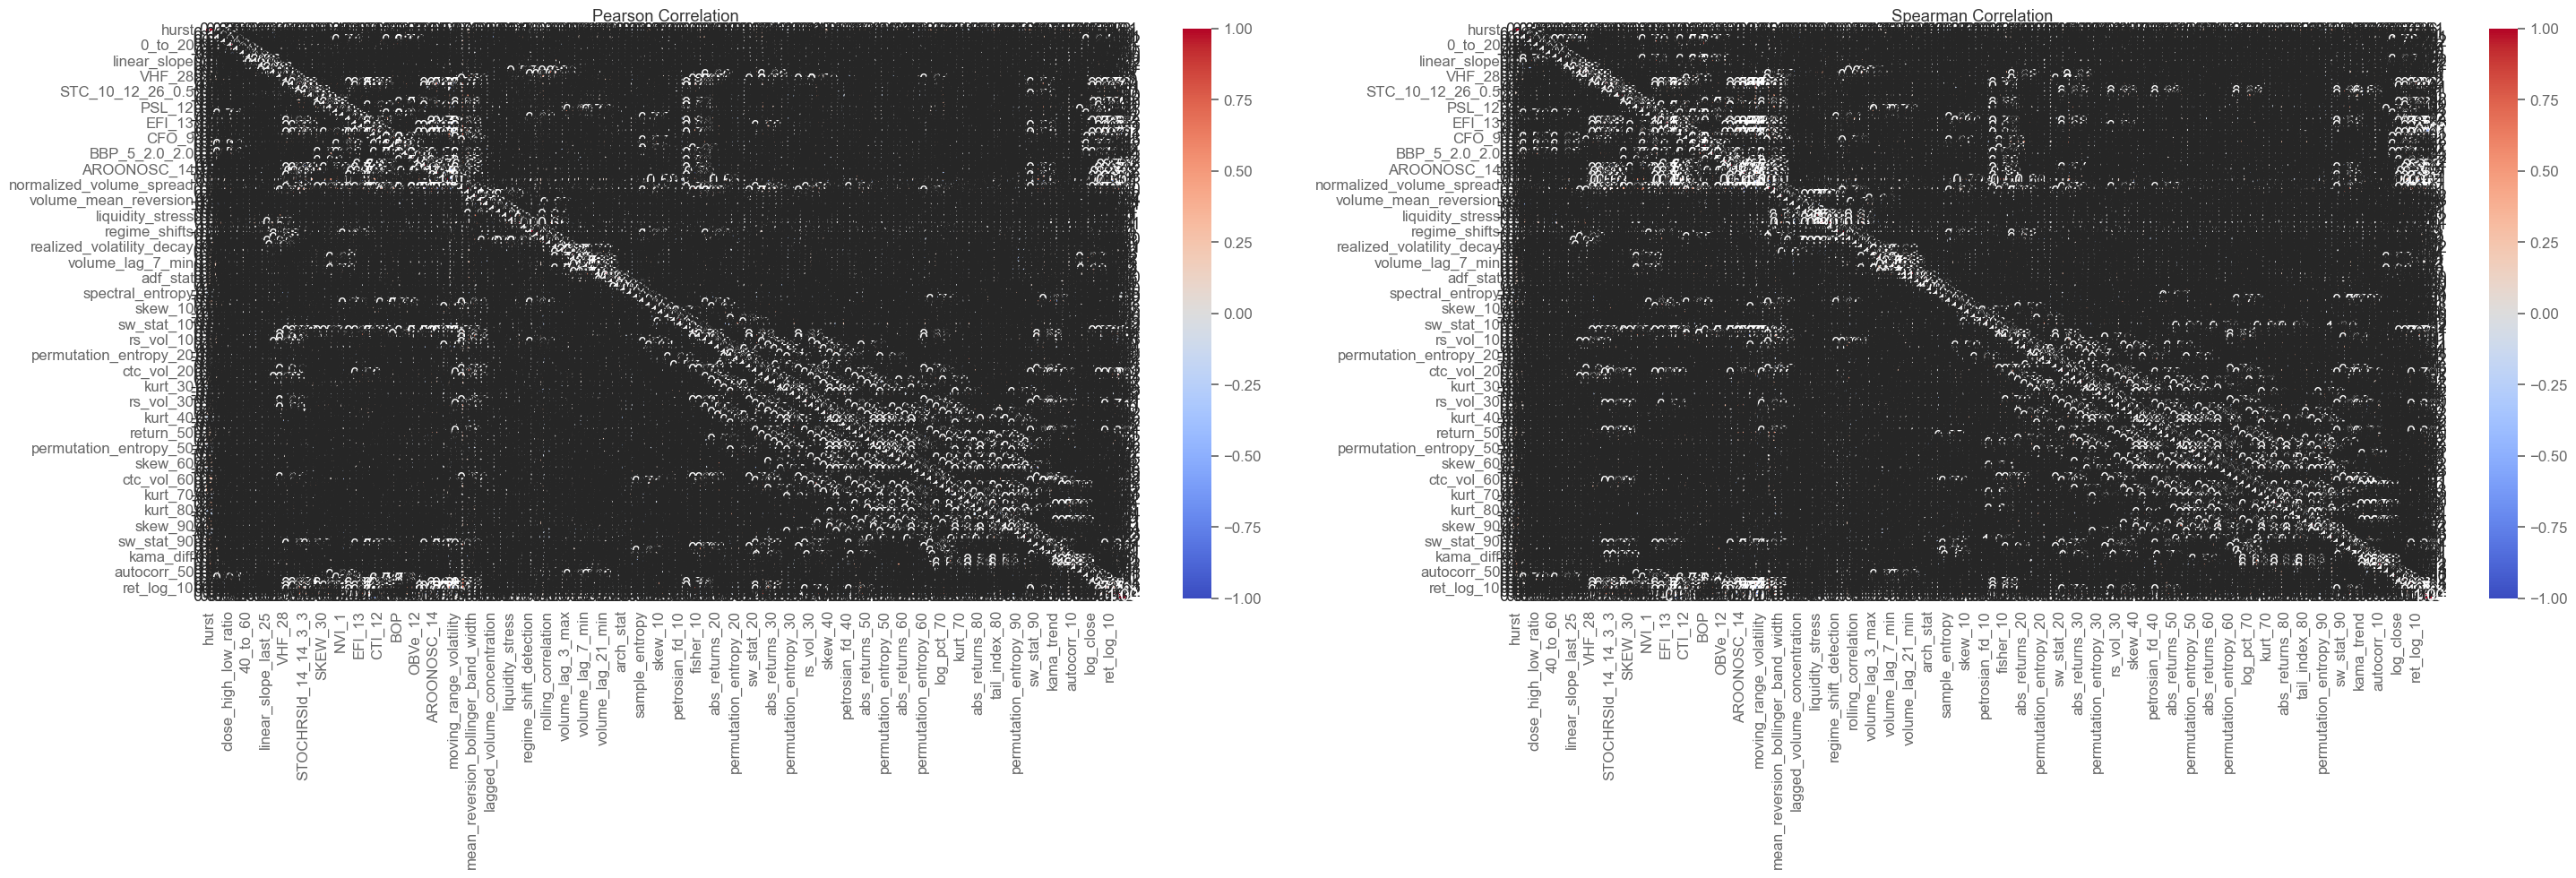

In [ ]:
def correlation_graphs(df):
    """
    Generate two heatmaps side by side to visualize Pearson and Spearman correlations.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing numerical features to compute correlations.

    Returns:
    --------
    None
        Displays a figure with two heatmaps:
        Left: Pearson correlation heatmap.
        - Right: Spearman correlation heatmap.
    """
    # Create a figure with two side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))  # Adjust size for proper spacing
    
    # Heatmap for Pearson correlation
    sns.heatmap(df.corr(), fmt=".2f", cmap="coolwarm", annot=True, vmin=-1, vmax=1, ax=ax1)
    ax1.set_title("Pearson Correlation")
    
    # Heatmap for Spearman correlation
    sns.heatmap(df.corr(method="spearman"), fmt=".2f", cmap="coolwarm", annot=True, vmin=-1, vmax=1, ax=ax2)
    ax2.set_title("Spearman Correlation")
    
    # Display the two heatmaps side by side
    plt.tight_layout()
    plt.show()

df_train = pd.concat((X_train_sc_df[vif_results_clean.index], y_train), axis=1)
correlation_graphs(df_train)

### Mutual information
Mutual Information (MI) is a metric that measures the dependency between two variables. Unlike correlation, it can capture both linear and non-linear relationships, making it a versatile tool for feature selection.

The value of MI ranges from 0 to infinity:
<ol>
    <li>A value of 0 means the two variables are independent.</li>
    <li>Higher values indicate a stronger dependency between the variables.</li> 
</ol>
<br>
In finance, where relationships between variables are often non-linear and complex, MI can provide valuable insights. 

In [28]:
# For a continous variable (regression)
#mi_scores = mutual_info_regression(X, y)

# For a dummy variable (classification)
mi_scores = mutual_info_classif(X_train_sc_df[vif_results_clean.index], y_train)
mi_df = pd.DataFrame({'Feature': X_train_sc_df[vif_results_clean.index].columns, 'Mutual Information': mi_scores}).sort_values(by='Mutual Information', ascending=False)
mi_df = mi_df.set_index("Feature")


# Summarize the info
linear_correlation_target = df_train.corr()["target"]*100
linear_correlation_target.name = "lr_dummy"

nonlinear_correlation_target = df_train.corr(method="spearman")["target"]*100
nonlinear_correlation_target.name = "nlr_dummy"

df_mi_vif = pd.concat((vif_results_clean, mi_df, linear_correlation_target, nonlinear_correlation_target), axis=1).dropna()
df_mi_vif.sort_values("Mutual Information", ascending=False).dropna()

,VIF,Mutual Information,lr_dummy,nlr_dummy
volume_lag_7_max,12.63,0.200444,1.703923,1.180354
moving_range_volatility,3.06,0.177420,3.507479,3.946624
DPO_20,1.55,0.176482,-52.457974,-56.139545
NVI_1,8.58,0.172952,0.060112,-0.520021
volume_lag_7_min,3.05,0.139540,1.057711,1.791279
...,...,...,...,...
autocorr_10,9.58,0.000000,-1.653655,-1.890610
autocorr_50,1.92,0.000000,-1.217022,-1.168916
ret_log_1,9.34,0.000000,-2.211902,-2.013599
ret_log_10,8.06,0.000000,-2.941021,-1.759304


Then we are going to filter the mutual_info_classif information. And the variabel df_filtered is containing the most important features.

In [30]:
df_filtered = df_mi_vif[
    (df_mi_vif['Mutual Information'] > 0.01) |
    (df_mi_vif['lr_dummy'].abs() > 10) |
    (df_mi_vif['nlr_dummy'].abs() > 10)
]

df_filtered

,VIF,Mutual Information,lr_dummy,nlr_dummy
NVI_1,8.58,0.172952,0.060112,-0.520021
ER_10,7.21,0.011652,2.066650,2.216132
DPO_20,1.55,0.176482,-52.457974,-56.139545
OBVe_12,1.95,0.013091,-1.712188,-1.753525
moving_range_volatility,3.06,0.177420,3.507479,3.946624
bidask_spread_ratio,1.19,0.011976,1.586478,1.758696
volume_lag_3_max,4.84,0.080066,2.223051,2.387749
volume_lag_3_min,3.12,0.101990,3.313308,3.835105
volume_lag_7_max,12.63,0.200444,1.703923,1.180354
volume_lag_7_min,3.05,0.139540,1.057711,1.791279


Now when we know the most important features, we can plot the two correlation matrixs again. And then we are able to see the diffrent correlations.

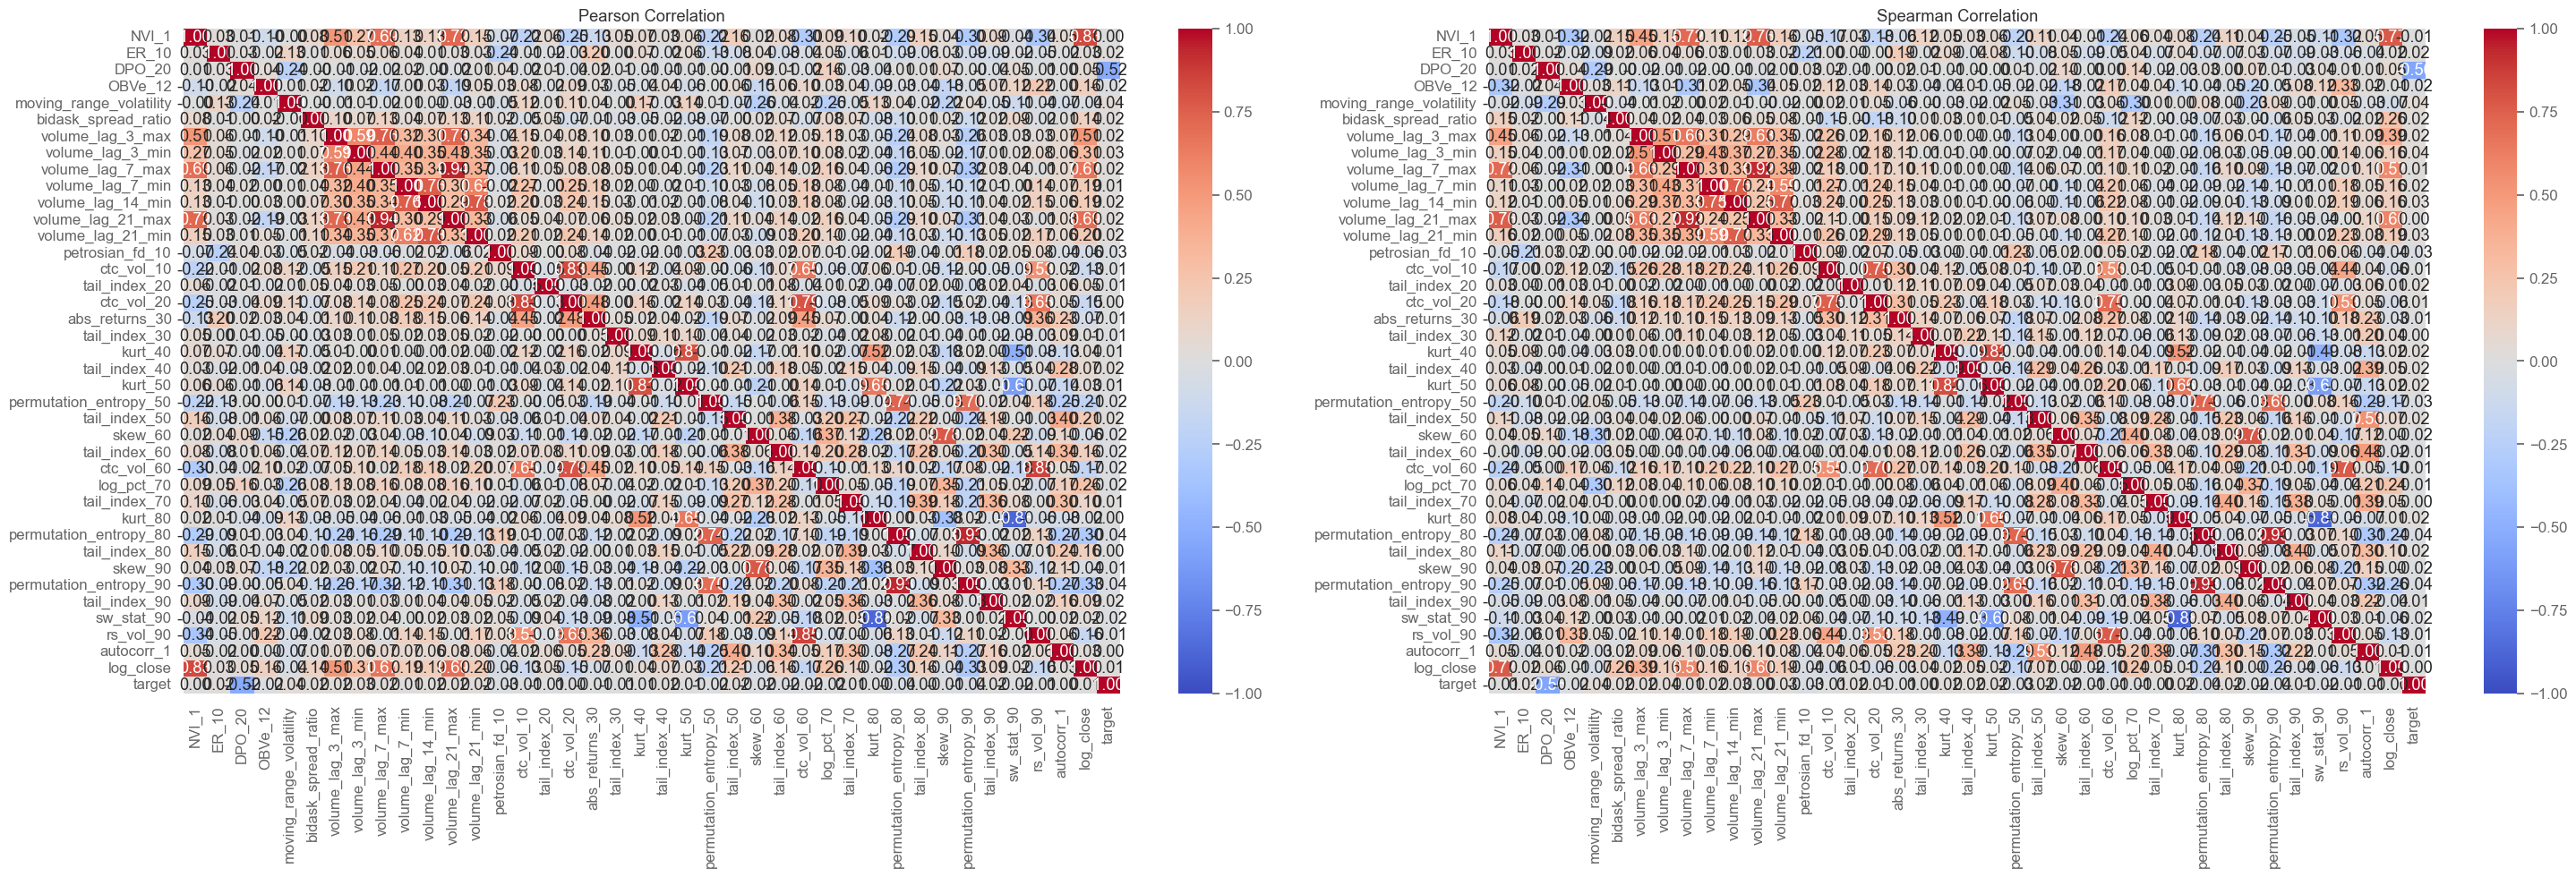

In [31]:
df_train_bis = pd.concat((X_train_sc_df[df_filtered.index], y_train), axis=1)
correlation_graphs(df_train_bis)

## Model testing

### Decision Tree Classifier
A Decision Tree Classifier is a supervised machine learning algorithm that categorizes data by recursively splitting it based on feature-driven decision rules. <br>

Each internal node represents a condition on a feature, branches denote the outcomes of those conditions and leaf nodes assign the final class label. This tree-based structure makes the model both interpretable and effective for classification tasks.
<br>
The used parameters:
<ol>
    <li>criterion: Metric used to evaluate split quality (gini, entropy, log_loss)</li>
    <li>max_depth: Maximum depth of the tree.</li>
    <li>min_samples_split: Minimum samples required to split a node.</li>
</ol>

We are using the grid search function to find the most optimal set of parameter. By using the Grid Search function we also implement cross validation in order to create a more robust model

In [32]:
dtc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dtc', DecisionTreeClassifier())
])

dtc_param_grid = {
    'dtc__max_depth': [3, 5, 10, 12, 15, 17, 20],
    'dtc__min_samples_split': [2, 5, 10],
    'dtc__criterion': ['gini', 'entropy']
}

grid_search_dtc = GridSearchCV(
    dtc_pipeline,
    dtc_param_grid,
    cv= tscv ,
    verbose=3,
    n_jobs=-1
)

grid_search_dtc.fit(train_data[df_filtered.index], train_data['target'])

print(grid_search_dtc.best_params_)
print(grid_search_dtc.best_score_)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
{'dtc__criterion': 'entropy', 'dtc__max_depth': 3, 'dtc__min_samples_split': 2}
0.7448218724109362


### KNeighbors Classifier
K-Nearest Neighbors (KNN) is a supervised machine learning algorithm generally used for classification but can also be used for regression tasks. It works by finding the "k" closest data points (neighbors) to a given input and makes a predictions based on the majority class (for classification) or the average value (for regression).
<br>
The used parameters:
<ol>
    <li>n_neighbors: Number of neighbors.</li> 
    <li>weights.</li>
    <li>metric: How the distances is measured</li>
</ol>

We are using the grid search function to find the most optimal set of parameter. By using the Grid Search function we also implement cross validation in order to create a more robust model

In [33]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # VIGTIG for KNN
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv= tscv ,
    verbose=3,
    n_jobs=-1
)

grid_search_knn.fit(train_data[df_filtered.index], train_data['target'])

print(grid_search_knn.best_params_)
print(grid_search_knn.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
0.6132560066280034


### Random Forest Classifier
Random Forest is a method that combines the predictions of multiple decision trees to produce a more accurate and stable result. It can be used for both classification and regression tasks. In classification tasks, Random Forest Classification predicts categorical outcomes based on the input data. It uses multiple decision trees and outputs the label that has the maximum votes among all the individual tree predictions.
<br>
The used parameters:
<ol>
    <li>max_depth: Maximum depth of each tree.</li> 
    <li>n_estimators: Number of trees in the forest.</li>
    <li>max_features: Number of features considered for splitting at each node.</li>
    <li>min_samples_leaf: Minimum samples required to be at a leaf node.</li>    
</ol>

We are using the grid search function to find the most optimal set of parameter. By using the Grid Search function we also implement cross validation in order to create a more robust model

In [34]:
rfc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rfc', RandomForestClassifier())
])

rfc_param_grid = {
    'rfc__max_depth': [3,5,7,10],
    'rfc__n_estimators': [100, 200, 300, 400, 500],
    'rfc__max_features': [10, 20, 30 , 40],
    'rfc__min_samples_leaf': [1, 2, 4]
}

grid_search_rfc = GridSearchCV(
    rfc_pipeline,
    rfc_param_grid,
    cv= tscv,
    verbose=3,
    n_jobs=-1
)

grid_search_rfc.fit(train_data[df_filtered.index], train_data['target'])

print(grid_search_rfc.best_params_)
print(grid_search_rfc.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
{'rfc__max_depth': 7, 'rfc__max_features': 20, 'rfc__min_samples_leaf': 4, 'rfc__n_estimators': 500}
0.7562551781275891


### SVC
Support Vector Classifier (SVC) is a type of Support Vector Machine (SVM) used for classification tasks. SVM is a supervised learning model that finds the hyperplane which best separates the data points of different classes in a high-dimensional space. The main goal of SVM is to maximize the margin between the hyperplane and the nearest data points (support vectors) from any class.
<br>
The used parameters:
<ol>
    <li>C: The regularization parameter that controls the trade-off between margin and misclassification error.</li> 
    <li>gamma: The kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels.</li>
    <li>Kernel: The kernel function used to transform the data into a higher-dimensional space. Common kernels include 'linear', 'poly', and 'rbf'.</li>
</ol>

We are using the grid search function to find the most optimal set of parameter. By using the Grid Search function we also implement cross validation in order to create a more robust model

In [35]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

svc_param_grid = {
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'svc__kernel': ['rbf']
}

grid_search_svc = GridSearchCV(
    svc_pipeline,
    svc_param_grid,
    cv= tscv,
    verbose=3,
    n_jobs=-1
)

grid_search_svc.fit(train_data[df_filtered.index], train_data['target'])

print(grid_search_svc.best_params_)
print(grid_search_svc.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
{'svc__C': 10, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
0.7315658657829329


## Creating the final model

In [53]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rfc', RandomForestClassifier(max_depth= 5, n_estimators= 30, max_features= 2, min_samples_leaf= 100))
])

rfc_param_grid = {
    'rfc__max_depth': [3,5,7,10],
    'rfc__n_estimators': [100, 200, 300, 400, 500],
    'rfc__max_features': [10, 20, 30 , 40],
    'rfc__min_samples_leaf': [1, 2, 4]
}

pipeline.fit(train_data[df_filtered.index], train_data['target'])
predicts = pipeline.predict(test_data[df_filtered.index]) 

print('Training set score: ' + str(pipeline.score(train_data[df_filtered.index], train_data['target'])))
print('Test set score: ' + str(pipeline.score(test_data[df_filtered.index], test_data['target'])))

Training set score: 0.7608725666160431
Test set score: 0.7277747101049145


In [57]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Below the confusion_matrix tell us that 459 True Negative, 300 False Negative, 193 False Positive and 859 True Positive predictions 

In [ ]:
confusion_matrix(predicts, test_data['target'])

array([[459, 193],
       [300, 859]])

Overall Performance:
<br>
Accuracy: 0.73 (73%)
The model correctly predicts 73% of all 1,811 observations.
This means roughly 3 out of 4 predictions are correct.
<br><br>
Class 0
<ol>
    <li>Support: 652 (actual number of class 0 instances).</li> 
    <li>Precision: 0.60 - The model correctly identifies 70% of all actual class 0 cases..</li>
    <li>Recall: 0.70 - The model correctly identifies 70% of all actual class 0 cases.</li>
    <li>F1-score: 0.65 - The harmonic mean of precision and recall, balancing both metrics.</li>
</ol>
The model is moderately good at detecting class 0. It captures most of the true class 0 cases (70%), but its precision is lower, meaning it makes a fair number of incorrect class 0 predictions.
<br>
Class 1
<ol>
    <li>Support: 1,159 (actual number of class 1 instances).</li> 
    <li>Precision: 0.82 - When the model predicts class 1, it is correct 82% of the time.</li>
    <li>Recall: 0.74 - The model correctly identifies 74% of all actual class 1 cases.</li>
    <li>F1-score: 0.78</li>
</ol>

In [59]:
print(classification_report(predicts, test_data['target']))

              precision    recall  f1-score   support

           0       0.60      0.70      0.65       652
           1       0.82      0.74      0.78      1159

    accuracy                           0.73      1811
   macro avg       0.71      0.72      0.71      1811
weighted avg       0.74      0.73      0.73      1811

